In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys 

main_dir = '../'
# task_grn_inference_dir = '../../'
output_dir = f"{main_dir}/output/"

# - local imports 
sys.path.append(main_dir)
from src.utils.util import get_canonical_pathways
pathways_df = get_canonical_pathways()

# Embedding

## Data1

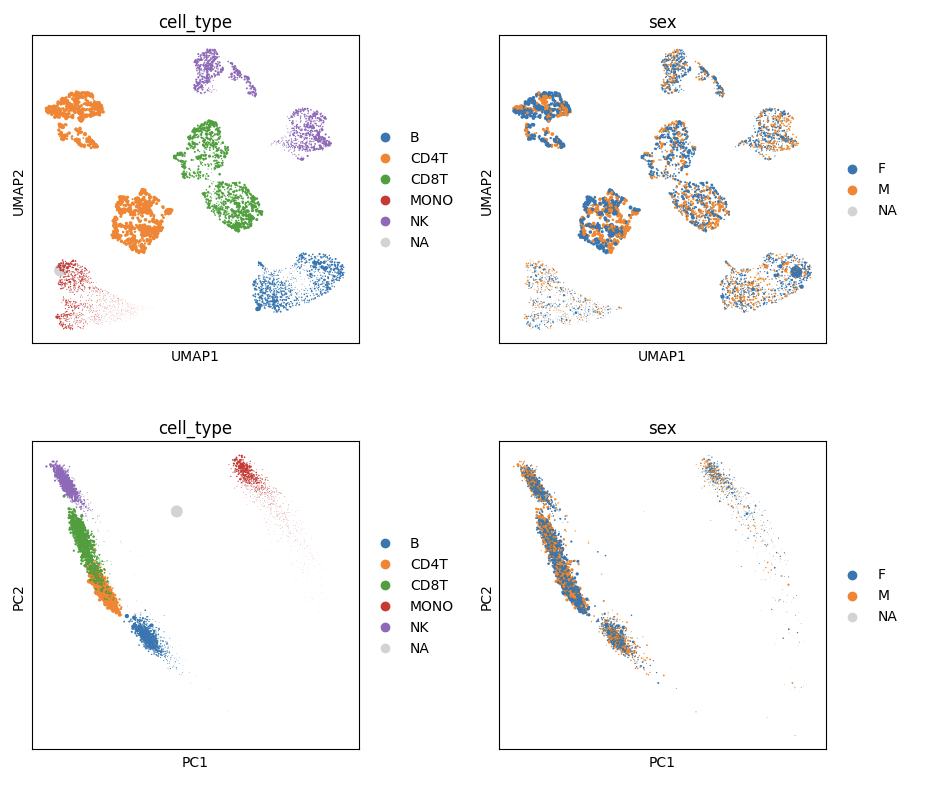

## Data7 (all)

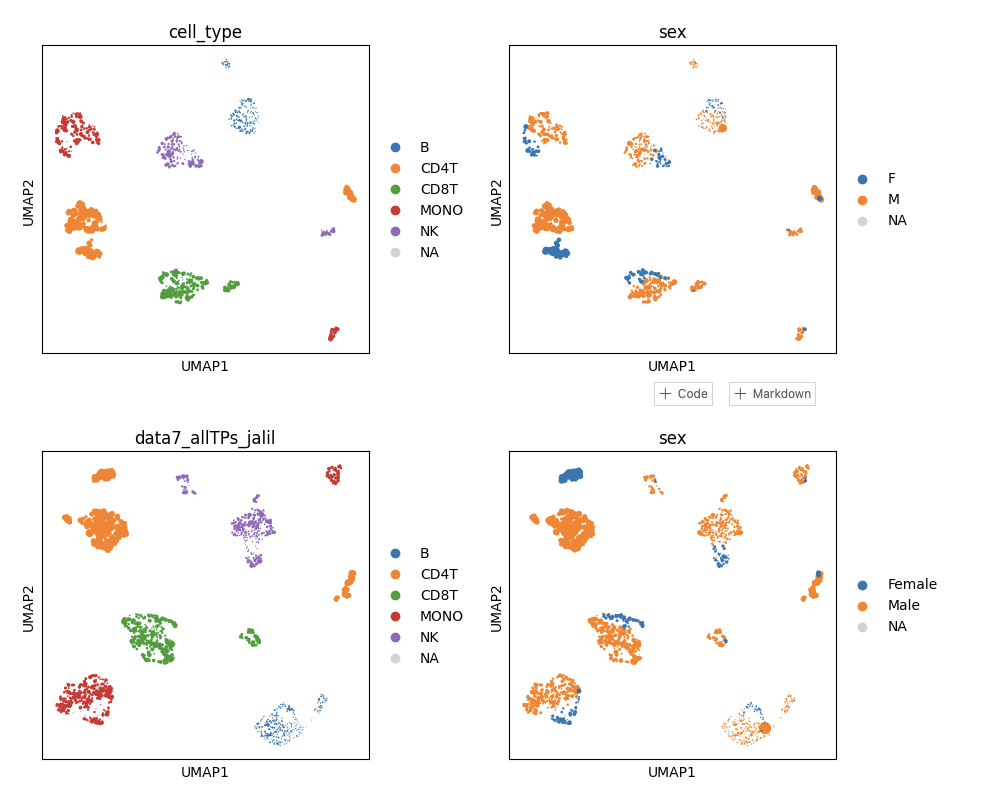

# TF activation

In [2]:
# - define a few functions 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def add_supp_cols(df, adj_pval_col='p_value_adj', effect_size_col='slope'):
    # Compute -log10(p_value_adj) for dot size
    df["neg_log10_adj_pval"] = -np.log10(df[adj_pval_col])
    
    # Determine color based on slope sign
    def determine_sign(x):
        if np.isnan(x):
            return "Inconsistent" 
        elif x > 0:
            return "Increased"
        else:
            return "Decreased"

    df["linear_trend"] = df[effect_size_col].apply(determine_sign)
    df["linear_trend"] = pd.Categorical(
        df["linear_trend"], 
        categories=["Increased", "Decreased", "Inconsistent"], 
        ordered=True
    )
    return df


def dotplot_tf_celltype(df, ax, color_col='linear_trend', size_col='neg_log10_adj_pval', title=None):
    palette = {name: color for name, color in zip(df[color_col].cat.categories, ["green", "red", "gray"])}
    color_legend = [mpatches.Patch(color=color, label=name) for name, color in palette.items()]

    # Capture scatter plot object
    scatter = sns.scatterplot(
        data=df, 
        x="cell_type", 
        y="tf", 
        size=size_col, 
        hue=color_col, 
        sizes=(1, 100),
        palette=palette, 
        edgecolor="black",
        legend=False,  # Disable automatic legend
        ax=ax
    )
    # Labels and formatting
    ax.set_ylabel("Transcription Factor")
    # ax.set_xlabel("Cell type")
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    # 1. Create Color Legend 
    color_legend_handle = plt.legend(handles=color_legend, title=color_col, loc=(1.1, .1), frameon=False)

    # 2. Create Size Legend 
    size_legend_values = np.linspace(df[size_col].min() , df[size_col].max(), num=6)
    size_legend_handles = [plt.scatter([], [], s=s * 20, color="black", label=f"{s:.1f}") for s in size_legend_values]
    size_legend_handle = plt.legend(handles=size_legend_handles, title=size_col, loc=(1.1, .4), frameon=False)
    plt.gca().add_artist(color_legend_handle)


In [13]:
stats_all = []
for cell_type in ['NK', 'B', 'CD4T', 'CD8T', 'MONO']:
# for cell_type in ['CD8T']:
    stats = pd.read_csv(f'{output_dir}/tf_activation/{cell_type}.csv')
    stats['cell_type'] = cell_type
    stats_all.append(stats)
stats_all = pd.concat(stats_all)
stats_all.reset_index(drop=True, inplace=True)
stats_all['cell_type'] = stats_all['cell_type'].astype('category')

In [14]:
stats_all_sig = stats_all[stats_all['p_value_adj'] < 0.05]
stats_all_sig

,tf,p_value_adj,slope,spearman_corr,r2,type,p_value_adj_expression,slope_expression,spearman_corr_expression,r2_expression,cell_type
4,ID2,3.298234e-07,-0.001141,-0.294037,0.099026,age,1.000000,-0.000476,-0.000563,0.001851,NK
5,FEZ1,7.536543e-06,0.001787,0.223231,0.047681,age,1.000000,0.000625,0.017178,0.000382,NK
6,MYC,6.449328e-06,-0.002912,-0.263625,0.077168,age,0.470231,-0.004663,-0.149454,0.013587,NK
7,DDIT3,1.443184e-02,NaN,NaN,0.012109,age,0.125070,NaN,NaN,0.014040,NK
25,MYC,8.433736e-06,-0.002912,-0.263625,0.077168,dpt,0.470231,-0.004663,-0.149454,0.013587,NK
...,...,...,...,...,...,...,...,...,...,...,...
194,EGR1,4.524241e-03,-0.027114,-0.105714,0.013408,age,1.000000,-0.001111,-0.011803,0.000169,MONO
196,NUCB1,2.862628e-04,0.005279,0.147656,0.021966,dpt,1.000000,0.001846,0.044724,0.002316,MONO
200,JUND,6.381621e-04,-0.154100,-0.134630,0.019155,centrality,1.000000,-0.001005,-0.047856,0.000408,MONO
201,FOSB,2.852857e-03,-0.242007,-0.129244,0.019534,centrality,1.000000,-0.002886,-0.089523,0.003480,MONO


In [28]:
# stats_all_sig_merged = stats_all_sig.merge(pathways_df, left_on='tf', right_index=True)
# df = stats_all_sig_merged
# plt.figure(figsize=(8, 5))
# ax = sns.stripplot(data=df, x="pathway", y="tf", jitter=True, dodge=True, size=8, alpha=0.7)

# # Add labels and style
# plt.xticks(rotation=45, ha="right")
# plt.xlabel("Pathway Membership")
# plt.ylabel("Transcription Factor (TF)")
# plt.title("TF Membership in Pathways")
# plt.grid(axis="y", linestyle="--", alpha=0.5)


/vol/tmp/users/jnourisa/ipykernel_2314749/3466792622.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/vol/tmp/users/jnourisa/ipykernel_2314749/2326908109.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/vol/tmp/users/jnourisa/ipykernel_2314749/2326908109.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


Text(0.5, 0.98, 'Sig. TFs in ageing')

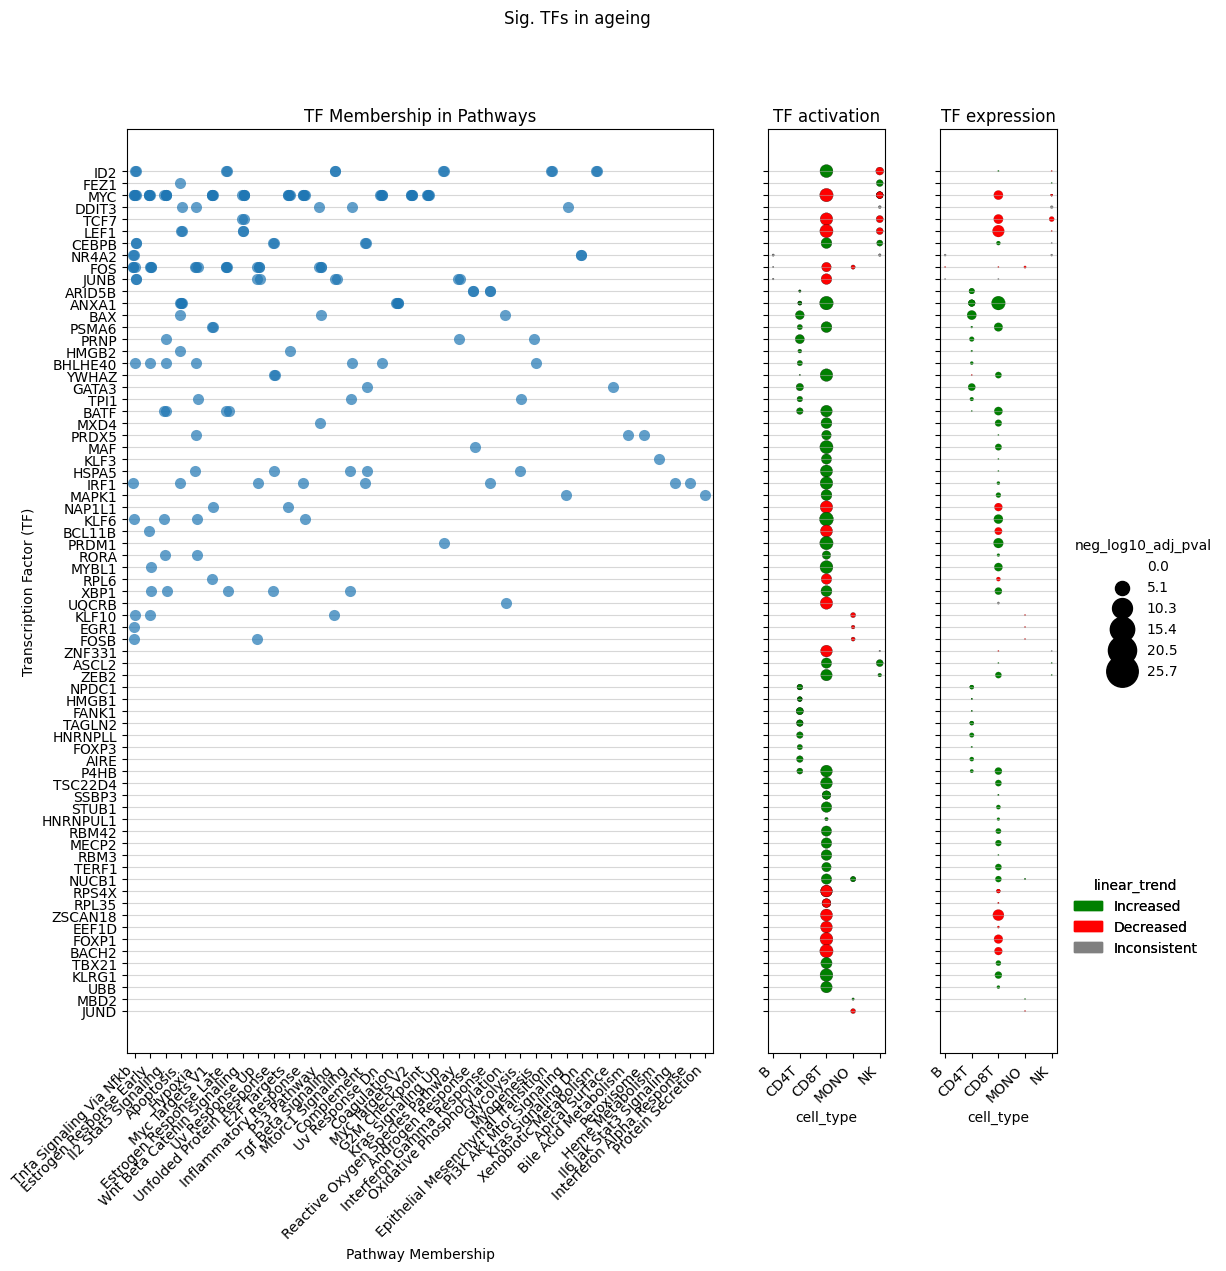

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(12, 12), 
                         gridspec_kw={'width_ratios': [1, .2, .2]}, 
                         sharey=True)# - plot TF activation stats
# - plot pathway association
ax = axes[0]
stats_all_sig_merged = stats_all_sig.merge(pathways_df, left_on='tf', right_index=True)
df = stats_all_sig_merged
pathway_order = df["pathway"].value_counts().index # Reverse order for left-heavy sorting
sns.stripplot(data=df, x="pathway", y="tf", jitter=True, dodge=True, 
                   size=8, alpha=0.7, order=pathway_order, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("Pathway Membership")
ax.set_ylabel("Transcription Factor (TF)")
ax.set_title("TF Membership in Pathways")
ax.grid(axis='y', alpha=0.5)

# - plot TF activation stats
ax = axes[1]
df = stats_all_sig.copy()
df = add_supp_cols(df, adj_pval_col='p_value_adj', effect_size_col='slope')
dotplot_tf_celltype(df, ax, color_col='linear_trend', size_col='neg_log10_adj_pval', title='TF activation')
ax.grid(axis='y', alpha=0.5)
# - plot TF exprssion stats

ax = axes[2]
df = add_supp_cols(df, adj_pval_col='p_value_adj_expression', effect_size_col='slope_expression')
dotplot_tf_celltype(df, ax, color_col='linear_trend', size_col='neg_log10_adj_pval', title='TF expression')
ax.grid(axis='y', alpha=0.5)

plt.suptitle("Sig. TFs in ageing")

In [47]:
pathways_df[pathways_df['pathway'].str.start()]

AttributeError: 'StringMethods' object has no attribute 'start'

# Over represented pathways

In [50]:
import pandas as pd
from scipy.stats import fisher_exact

# Example threshold for significance
pval_threshold = 0.05  

# Prepare pathway mapping
def get_pathway_enrichment(stats_all, pathway_df, pval_threshold=0.05):
    enriched_results = []

    # Iterate over each unique cell type
    for cell_type, df_cell in stats_all.groupby("cell_type"):
        # Get significant TFs for this cell type
        significant_tfs = set(df_cell[df_cell["p_value_adj"] < pval_threshold]["tf"])
        all_tfs = set(df_cell["tf"])  # All TFs tested in this cell type
        
        # Map genes (TFs) to pathways
        pathway_counts = pathway_df.groupby("pathway")["gene"].apply(set)
        
        # Perform enrichment analysis for each pathway
        for pathway, genes_in_pathway in pathway_counts.items():
            # Overlap with significant TFs
            overlap = significant_tfs & genes_in_pathway
            
            # Fisher’s exact test setup
            a = len(overlap)  # TFs in pathway & significant
            b = len(genes_in_pathway - significant_tfs)  # TFs in pathway but not significant
            c = len(significant_tfs - genes_in_pathway)  # Significant TFs not in pathway
            d = len(all_tfs - significant_tfs - genes_in_pathway)  # Rest of TFs
            # Only test if there is at least some overlap
            if a > 0:
                odds_ratio, p_value = fisher_exact([[a, b], [c, d]], alternative="greater")
                if 'Tnfa' in pathway:
                    print(f"{cell_type} - significant_tfs {len(significant_tfs)}, pathway: {pathway} - overlap: {a} - remaining genes: {b} - remaining sig TFs:{c} - rest of tfs: {d}")

                    print(f"odds_ratio: {odds_ratio}, p_value: {p_value} \n")
                enriched_results.append([cell_type, pathway, a, p_value])

    # Convert to DataFrame
    enriched_df = pd.DataFrame(enriched_results, columns=["cell_type", "pathway", "overlap", "p_value"])
    # enriched_df["p_adjusted"] = enriched_df["p_value"] * len(enriched_df)  # Bonferroni correction
    # enriched_df = enriched_df.sort_values(["cell_type", "p_adjusted"])
    
    return enriched_df
enriched_df = get_pathway_enrichment(stats_all.reset_index(), pathways_df.reset_index(), pval_threshold=0.05)
enriched_df[enriched_df['p_value']<0.05]

B - significant_tfs 3, pathway: Tnfa Signaling Via Nfkb - overlap: 3 - remaining genes: 197 - remaining sig TFs:0 - rest of tfs: 20
odds_ratio: inf, p_value: 0.7502827698881488 

CD4T - significant_tfs 19, pathway: Tnfa Signaling Via Nfkb - overlap: 1 - remaining genes: 199 - remaining sig TFs:18 - rest of tfs: 17
odds_ratio: 0.004745951982132886, p_value: 1.0 

CD8T - significant_tfs 49, pathway: Tnfa Signaling Via Nfkb - overlap: 7 - remaining genes: 193 - remaining sig TFs:42 - rest of tfs: 1
odds_ratio: 0.0008635578583765112, p_value: 1.0 

MONO - significant_tfs 7, pathway: Tnfa Signaling Via Nfkb - overlap: 4 - remaining genes: 196 - remaining sig TFs:3 - rest of tfs: 23
odds_ratio: 0.1564625850340136, p_value: 0.996141193050851 

NK - significant_tfs 11, pathway: Tnfa Signaling Via Nfkb - overlap: 4 - remaining genes: 196 - remaining sig TFs:7 - rest of tfs: 24
odds_ratio: 0.06997084548104957, p_value: 0.9999945210870955 



,cell_type,pathway,overlap,p_value


rma.mv (metafor)